# 05 · Kampanyanın etkisini ölçmek: A/B testi tasarımı

Kupon simülasyonundaki en kritik iki varsayım — **kupon talebi ne kadar artırır** ve **yeni kullanıcılar kalır mı** —
ancak bir deneyle ölçülebilir. Bu notebook, kampanya gerçekten uygulansaydı nasıl test edileceğini tasarlar.

## 1. Deney tasarımı

| Unsur | Karar |
|---|---|
| **Hipotez** | Zirve saatlerde geçerli %20 kupon, hedef ilçelerdeki yeni kullanıcıların zirve saatte yolculuk yapma oranını artırır |
| **Birim** | Kullanıcı (hedef ilçelerde uygulamayı ilk kez açan kişiler) |
| **Gruplar** | %50 test (kupon gösterilir), %50 kontrol (kupon yok) — rastgele atama |
| **Ana metrik** | İlk 4 haftada en az 1 zirve saat yolculuğu yapanların oranı (dönüşüm) |
| **İkincil metrikler** | Kullanıcı başına yolculuk sayısı, 8. haftada hâlâ aktif olma (kalıcılık) |
| **Koruma metrikleri** | Kullanıcı başına katkı marjı (indirim zarar ettirmesin), müşteri şikayetleri |
| **Karar kuralı** | Ana metrikte anlamlı artış **ve** katkı marjı negatif değilse → kampanyayı yaygınlaştır |

**Neden ilçe bazında değil, kullanıcı bazında rastgele atama?** Elimizde sadece birkaç hedef ilçe var.
İlçeleri test/kontrol diye ayırırsak ilçeler arasındaki doğal farklar (hava, etkinlik, yol çalışması) sonucu bozar
ve istatistiksel güç çok düşük olur. Kullanıcı bazında atama binlerce bağımsız gözlem sağlar.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest, confint_proportions_2indep
from gorsel import *
stil_uygula()

## 2. Örneklem büyüklüğü

**Varsayım:** Kupon olmadan, hedef ilçelerdeki yeni kullanıcıların **%12'si** ilk 4 haftada zirve saatte en az bir yolculuk yapıyor.
Yakalamak istediğimiz en küçük etki (MDE) ne olursa olsun, %5 anlamlılık ve %80 güç için grup başına gereken kullanıcı sayısı:

In [2]:
BAZ = 0.12
guc = NormalIndPower()
satir = []
for goreli in [0.05, 0.10, 0.15, 0.20, 0.30]:
    hedef = BAZ * (1 + goreli)
    n = guc.solve_power(effect_size=proportion_effectsize(hedef, BAZ), alpha=0.05, power=0.80, ratio=1)
    satir.append({"yakalanacak etki": f"+%{goreli*100:.0f} (%{BAZ*100:.0f} → %{hedef*100:.1f})",
                  "grup başına kullanıcı": int(np.ceil(n)), "toplam": int(np.ceil(n)) * 2})
orneklem = pd.DataFrame(satir)
orneklem

,yakalanacak etki,grup başına kullanıcı,toplam
0,+%5 (%12 → %12.6),47031,94062
1,+%10 (%12 → %13.2),11999,23998
2,+%15 (%12 → %13.8),5438,10876
3,+%20 (%12 → %14.4),3117,6234
4,+%30 (%12 → %15.6),1436,2872


**Süre:** Hedef 5 ilçede haftada yaklaşık **3.000 yeni kullanıcı** geldiğini varsayarsak (varsayım),
+%15'lik bir etkiyi yakalamak için gereken süre:

In [3]:
HAFTALIK_YENI = 3000
gerekli = orneklem.loc[orneklem["yakalanacak etki"].str.startswith("+%15"), "toplam"].iloc[0]
hafta = int(np.ceil(gerekli / HAFTALIK_YENI))
print(f"Toplam {gerekli:,} kullanıcı → yaklaşık {hafta} hafta kayıt + 4 hafta izleme = {hafta + 4} hafta")

Toplam 10,876 kullanıcı → yaklaşık 4 hafta kayıt + 4 hafta izleme = 8 hafta


## 3. Analiz nasıl yapılır? (sentetik veriyle örnek)

> ⚠️ Aşağıdaki veri **sentetik**tir, yani gerçek değil; analiz adımlarını göstermek için üretildi.
> Gerçek kampanyada aynı kod şirketin kullanıcı verisiyle çalıştırılır.

In [4]:
rng = np.random.default_rng(7)
n = int(orneklem.loc[orneklem["yakalanacak etki"].str.startswith("+%15"), "grup başına kullanıcı"].iloc[0])
kontrol = rng.binomial(1, 0.120, n)
test    = rng.binomial(1, 0.140, n)      # "gerçek" etki: +2 puan (sentetik)

z, p = proportions_ztest([test.sum(), kontrol.sum()], [n, n], alternative="two-sided")
alt, ust = confint_proportions_2indep(test.sum(), n, kontrol.sum(), n, method="wald")
print(f"Kontrol dönüşüm: %{kontrol.mean()*100:.2f}")
print(f"Test dönüşüm   : %{test.mean()*100:.2f}")
print(f"Fark           : {100*(test.mean()-kontrol.mean()):+.2f} puan  (%95 GA: {100*alt:+.2f} … {100*ust:+.2f})")
print(f"p-değeri       : {p:.4f}  → {'anlamlı' if p < 0.05 else 'anlamlı değil'}")

Kontrol dönüşüm: %12.06
Test dönüşüm   : %14.86
Fark           : +2.80 puan  (%95 GA: +1.51 … +4.08)
p-değeri       : 0.0000  → anlamlı


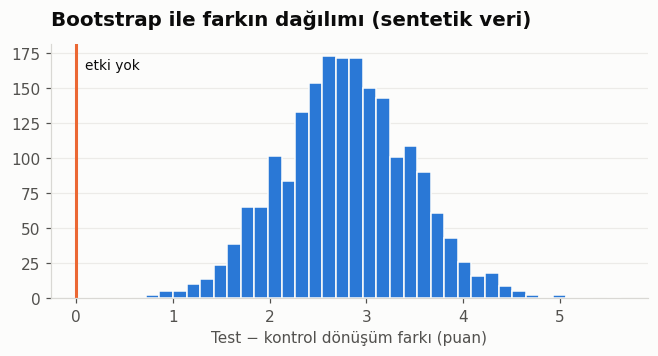

In [5]:
fig, ax = plt.subplots(figsize=(7, 3))
farklar = []
for _ in range(2000):   # bootstrap: farkın belirsizliğini görselleştirmek için
    k = rng.choice(kontrol, n); t = rng.choice(test, n)
    farklar.append((t.mean() - k.mean()) * 100)
ax.hist(farklar, bins=40, color=MAVI, edgecolor=ZEMIN, linewidth=1)
ax.axvline(0, color=TURUNCU, linewidth=2)
ax.annotate("etki yok", (0, ax.get_ylim()[1] * 0.9), xytext=(6, 0), textcoords="offset points", color=YAZI, fontsize=9)
ax.set_xlabel("Test − kontrol dönüşüm farkı (puan)")
ax.set_title("Bootstrap ile farkın dağılımı (sentetik veri)")
kaydet(fig, "05_ab_bootstrap")

## 4. Sık yapılan hatalar ve önlemleri

| Risk | Ne olur? | Önlem |
|---|---|---|
| **Ara sonuçlara bakıp erken durdurmak** (peeking) | Yanlış pozitif oranı %5'ten çok daha yükselir | Süre ve örneklem önceden sabitlenir |
| **Yenilik etkisi** | Kupon ilk hafta ilgi çeker, sonra söner | Ana metriğe ek olarak 8. hafta kalıcılığı izlenir |
| **Sızıntı** | Kontrol grubu arkadaşından kupon kodu alır | Kupon kişiye özel ve tek kullanımlık |
| **Çoklu metrik** | 10 metriğe bakınca biri şans eseri anlamlı çıkar | Tek ana metrik önceden belirlenir |
| **Mevsimsellik** | Yağmurlu hafta herkesi etkiler | Test ve kontrol aynı anda çalışır, karşılaştırma eş zamanlı |

## Sonuç

Kampanya, **5 hedef ilçede, kullanıcı bazında rastgele atamalı**, yaklaşık 8 haftalık (4 hafta kayıt + 4 hafta izleme) bir A/B testiyle ölçülmeli.
Test sonucu, kupon simülasyonundaki **esneklik** ve **kalıcılık** varsayımlarının yerine gerçek değerleri koyarak
kampanyanın kârlı olup olmayacağına kesin karar vermeyi sağlar.